# Sales Prediction Using Python

### Oasis Infobyte Data Science Internship (OIBSIP)

**Task 5**

**Author:** Biswajit Senapati

---

## Importing Required Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

In [3]:
df = pd.read_csv("datasets/Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [5]:
# Column names
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [8]:
# Check missing values
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [9]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Descriptive statistics
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### Observation

- The dataset contains advertising expenditure on **TV**, **Radio**, and **Newspaper**, along with the corresponding **Sales**.
- No missing values are present in the dataset.
- Duplicate rows, if any, should be removed before model training.
- The descriptive statistics provide information about the distribution of each numerical feature.

## Exploratory Data Analysis (EDA)

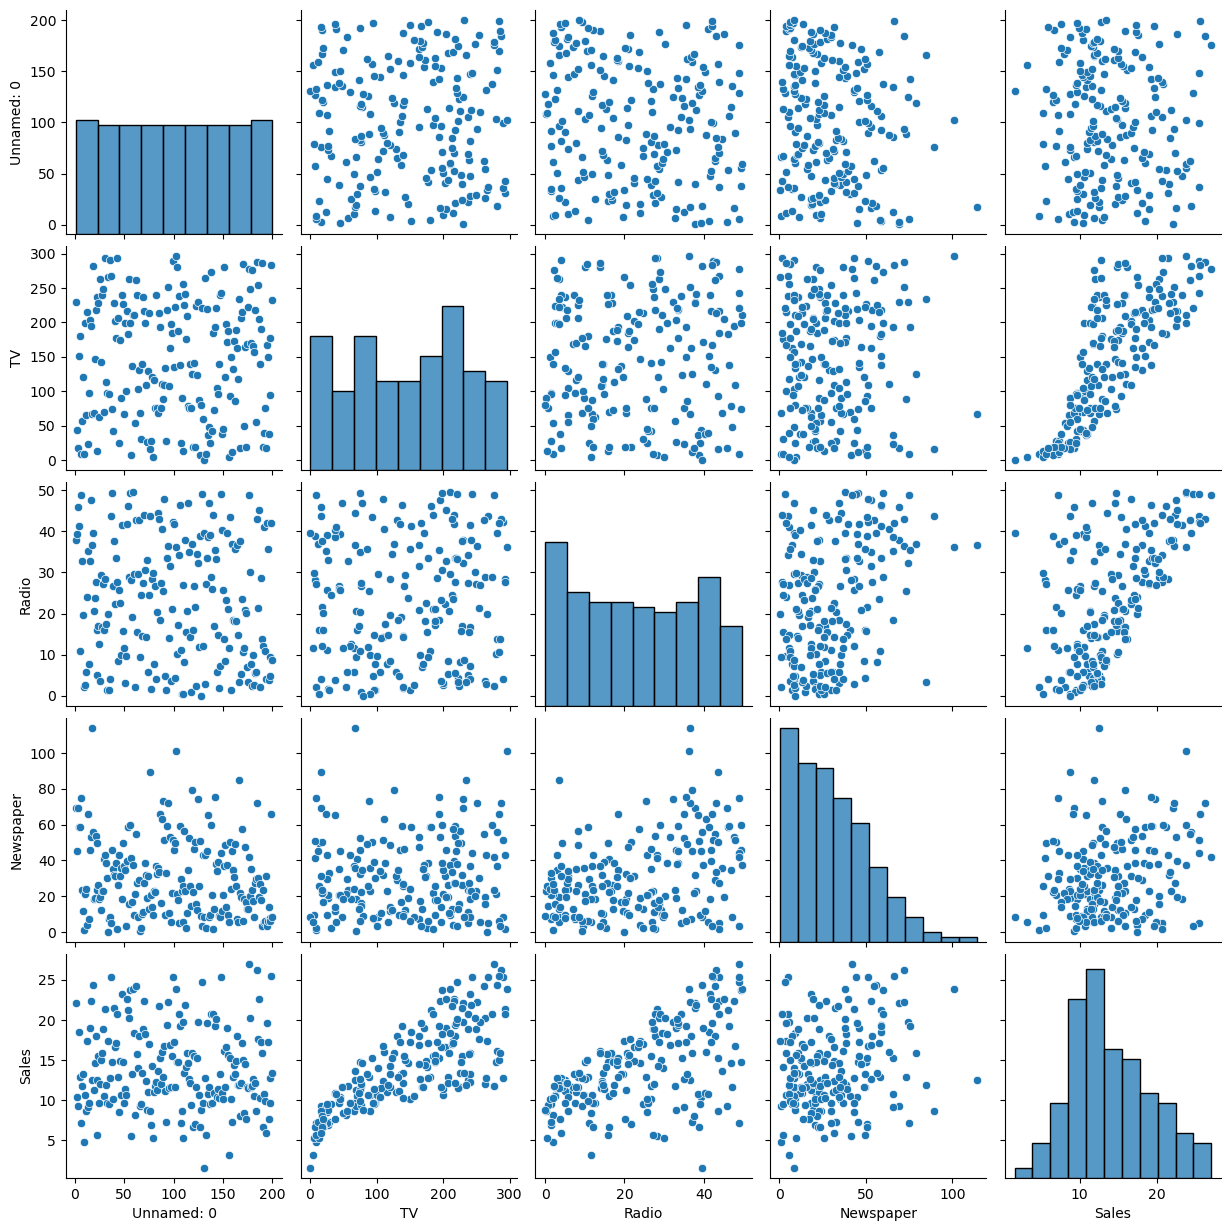

In [12]:
sns.pairplot(df)
plt.show()

### Observation

The pairplot indicates that **TV** and **Radio** advertising expenditures exhibit a stronger positive relationship with **Sales** compared to **Newspaper** advertising.

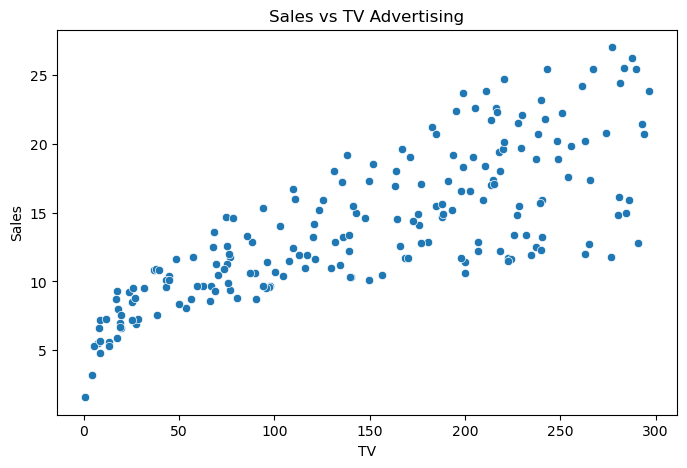

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("Sales vs TV Advertising")
plt.show()

### Observation

Sales generally increase as TV advertising expenditure increases, indicating a strong positive linear relationship.

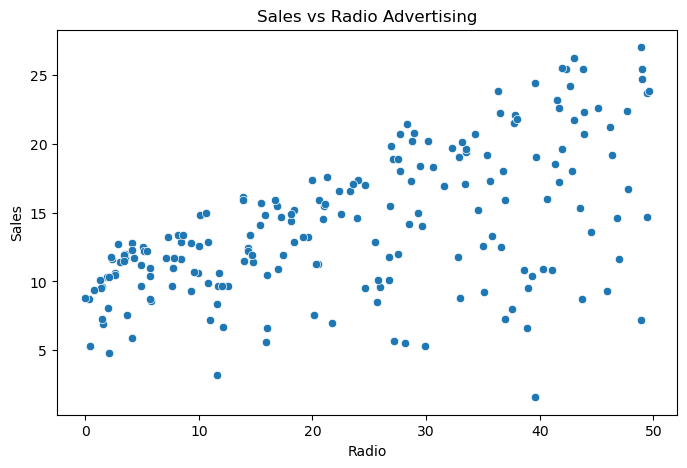

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Sales vs Radio Advertising")
plt.show()

### Observation

Radio advertising also demonstrates a positive relationship with sales, although the correlation is slightly weaker than that of TV advertising.

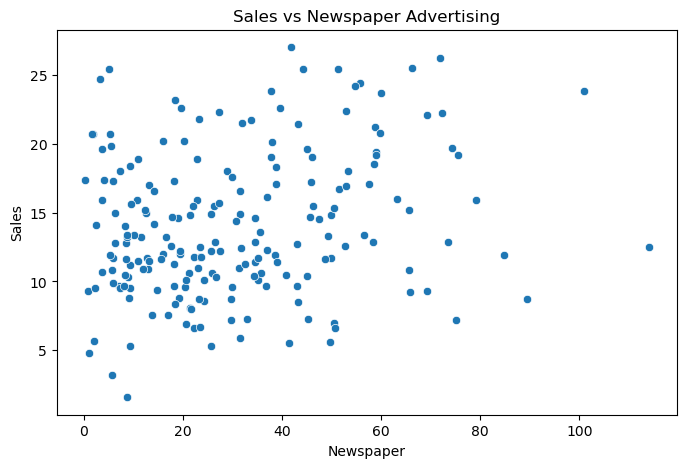

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title("Sales vs Newspaper Advertising")
plt.show()

### Observation

Newspaper advertising shows a relatively weak relationship with sales, suggesting it may have a smaller impact on the prediction model.

## Correlation Analysis

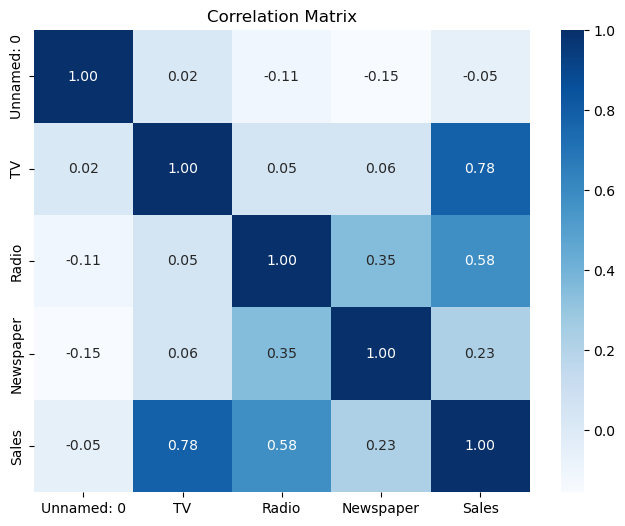

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Observation

- TV advertising has the strongest positive correlation with Sales.
- Radio advertising also shows a positive correlation with Sales.
- Newspaper advertising has the weakest correlation with Sales.

## Feature Selection

In [17]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

## Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Model Evaluation

In [20]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print(f"MAE : {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")

Linear Regression Performance
MAE : 1.46
RMSE: 1.78
R² Score: 0.8994


### Observation

The Linear Regression model provides a strong baseline for predicting sales and demonstrates how advertising expenditure influences product sales.

## Random Forest Regressor

In [21]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Performance
MAE : 0.62
RMSE: 0.77
R² Score: 0.9813


## Residual Analysis

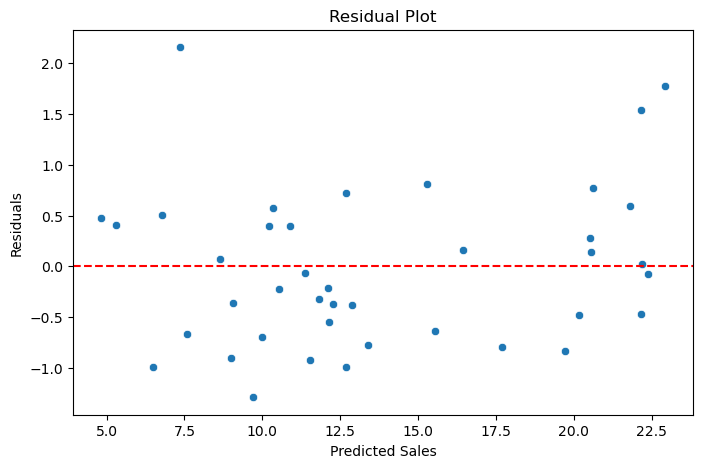

In [23]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=rf_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Observation

The residuals are randomly scattered around the zero line without any obvious pattern. This indicates that the Random Forest model captures the relationship between advertising expenditure and sales effectively.

## Feature Importance

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


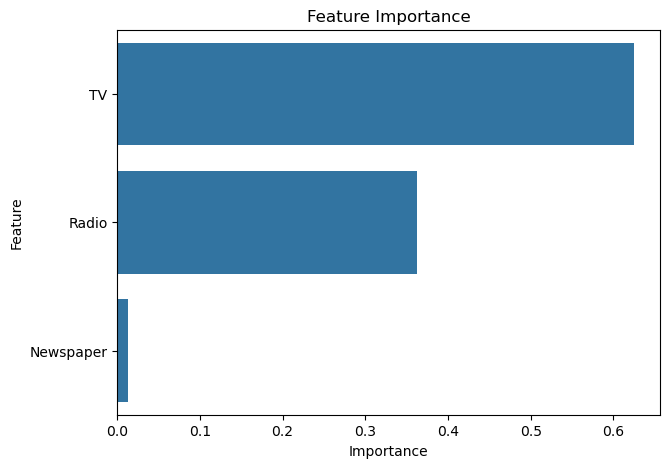

In [25]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

### Observation

The feature importance plot shows the relative contribution of each advertising channel in predicting sales. The channel with the highest importance has the greatest influence on the prediction model.

## Actual vs Predicted Sales

The following visualization compares the actual sales values with the values predicted by the Random Forest model.

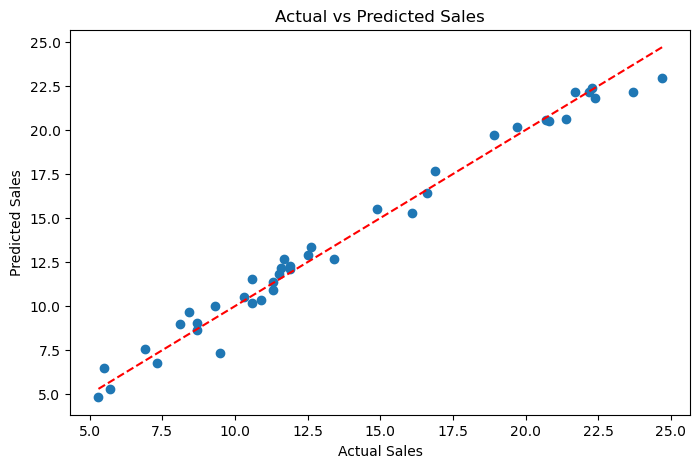

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Model Comparison

The performance of both regression models is compared using MAE, RMSE, and R² Score.

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R² Score": [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


In [29]:
best_model = comparison.loc[
    comparison["R² Score"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model       Random Forest
MAE                0.6201
RMSE             0.768591
R² Score         0.981284
Name: 1, dtype: object


# Conclusion

In this project, a sales prediction system was developed using advertising expenditure across TV, Radio, and Newspaper channels.

Exploratory Data Analysis revealed that TV and Radio advertising have a stronger relationship with product sales than Newspaper advertising. Two regression models—Linear Regression and Random Forest Regressor—were trained and evaluated using MAE, RMSE, and R² Score.

Among the evaluated models, the one with the higher R² score demonstrated better predictive performance and was selected as the preferred model for sales prediction.

Overall, this project demonstrates how machine learning can be applied to analyze advertising data and support data-driven business decisions.